![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Model-Agnostic Interpretation with LIME for Image Analysis

In this notebook, we will demonstrate how to use the Local Interpretable Model-agnostic Explanations (LIME) method for image classification models. As an example, we classify galaxies by their shape.

--------

## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. To start working on the notebook, click on the following button. This will open this page in the Colab environment, and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-cnn/4-Tutorial_LIME_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Google Colab, follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
At this point, a folder has been created in your Drive, and you can navigate it through the lefthand panel in Google Colab. You might also have received an email that informs you about the access on your Google Drive.

In [1]:
# Mount drive folder to dbe abale to download repo
# from google.colab import drive
# drive.mount('/content/drive')

# Switch to correct folder'
# %cd /content/drive/MyDrive

In [2]:
# Don't run this cell if you already cloned the repo 
# %rm -r XAI-Tutorials
# !git clone --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [3]:
# Install al required dependencies and package versions
# %cd XAI-Tutorials
# !pip install -r requirements_xai-for-cnn.txt
# %cd xai-for-cnn

### Imports

Let's start with importing all required Python packages.

In [4]:
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries

import torch

import sys
sys.path.append('./')
sys.path.append('../models')
import utils
from model_galaxy import load_galaxy_model, GALAXY_CLASSES

import matplotlib.pyplot as plt
%matplotlib inline

Now, we fix the random seeds to ensure reproducible results, as we work with (pseudo) random numbers.

In [5]:
# assert reproducible random number generation
seed = 1
np.random.seed(seed)
torch.manual_seed(seed)

--------

## Data and Model Loading

Let's use an image of a galaxy. The images come from [Galaxy MNIST](https://github.com/mwalmsley/galaxy_mnist), a set of galaxy images from the Galaxy Zoo project, where volunteers classified galaxies by their shape. Each image is sorted into one of four classes: **smooth round**, **smooth cigar**, **edge-on disk** and **unbarred spiral**.

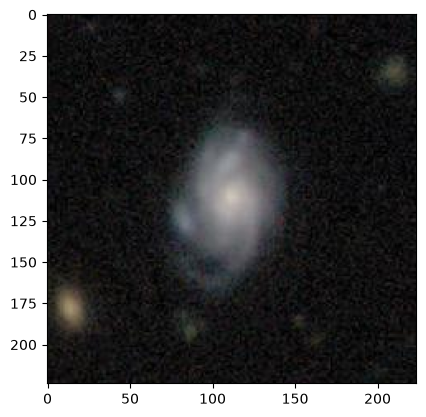

In [6]:
file_img = '../data/images/galaxies/test_galaxy_827.jpg'

img = utils.read_image_PIL(file_img)
plt.imshow(img)

We have to apply some transformations to ensure the input data has the correct format and is optimized for model training and inference. If you want to know more about these transformations, you can have a look at the [*utils.py*](utils.py) file.

In [7]:
# load function to resize and center crop
pill_transf = utils.get_pil_transform()

As model, we use a ResNet-18 architecture ([He et al., 2015](https://arxiv.org/pdf/1512.03385.pdf)) that was pretrained on ImageNet and then fine-tuned on the galaxy images. ResNet introduced skip connections, which let the gradient bypass layers and made it possible to train much deeper networks than before. Only the classification head was replaced, so the model predicts one of the four galaxy classes instead of the 1000 ImageNet classes.

The fine-tuned weights are stored in the repository, so nothing has to be trained here.

In [8]:
model = load_galaxy_model('../models/model_galaxy_weights.pth')

Predictions for a batch of images can be generated through the ```batch_predict``` function, which returns a batch of predicted probabilities for each class. Then, we extract the index of the class with the highest probability in the flattened array, indicating the predicted class label.

In [9]:
# Make preditction
pred = utils.batch_predict([pill_transf(img)], model)

# Extract class with highest prbability
top_class = pred.squeeze().argmax()
print(f"The predicted class with the highest probability is: {top_class}")

The predicted class with the highest probability is: 3


The four classes are listed in `GALAXY_CLASSES`, so we can translate the index into a name and check whether the prediction is correct.

In [10]:
for i, (name, p) in enumerate(zip(GALAXY_CLASSES, pred.squeeze())):
    marker = "  <- predicted" if i == top_class else ""
    print(f"{i}: {name:16s} {p:.3f}{marker}")

0: smooth round     0.000
1: smooth cigar     0.000
2: edge-on disk     0.001
3: unbarred spiral  0.999  <- predicted


## Now, what does my model think is important in the data?

**We prepared a small [Introduction to LIME](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/lime.html) for you, to help you understand how this method works. In the section [LIME for Image Classification](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/lime.html#lime-for-image-classification) we prepared an introduction on how to apply LIME on image data.**

*Note: we provide all references [here](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/lime.html#references).*

<font color='green'>

#### Question 1: What is a surrogate model?

<font color='grey'>

#### Your Answer: 
It’s an interpretable model, such as linear or tree models, that approximates the prediction of a more complex model.


<font color='green'>

#### Question 2: How is LIME using surrogate models to explain a model prediction?

<font color='grey'>

#### Your Answer: 
It creates the dataset from n perturbed images and lets the complex model make predictions for those perturbed images. This data set is then used to fit a surrogate model which can than be analysed to identify important features.

Now, let's use LIME to get insights into the image classification model. To utilize LIME for image explanations, the first step is to instantiate the ```LimeImageExplainer()``` class. Subsequently, the ```explain_instance``` method is employed with the following parameters:

- ```image```: the image represented as a Numpy array.
- ```classifier_fn```: the model used for making predictions.
- ```segmentation_fn```: the model used for segmentation of superpixels. Segmentation models are taken from [scikit-image](https://scikit-image.org/docs/stable/api/skimage.segmentation.html).
- ```top_labels```: the number of top classes for which explanations are generated.
- ```hide_color```: the color assigned to non-activated superpixels (set to a specific color, or 'avg' to use the mean over the superpixel region).
- ```num_samples```: the size of the neighborhood to learn the linear model.
- ```random_seed```: to ensure reproducibility in the segmentation, set the random seed for consistent results.
  
For more details about all the possible parameters, check out the [LIME documentation](https://lime-ml.readthedocs.io/en/latest/lime.html#module-lime.lime_image).
 
In our specific instance, explanations are generated for the top 5 classes, and the background color for non-activated superpixels is set to black.

In [11]:
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(image=np.array(pill_transf(img)), 
                                         classifier_fn=lambda images: utils.batch_predict(images, model), 
                                         top_labels=5, 
                                         hide_color=None, 
                                         num_samples=1000,
                                         random_seed=42) 

To visualize the instance explanation, the ```get_image_and_mask``` method can be utilized with the following configurable parameters:

- ```label```: the label for which the explanation is desired.
- ```positive_only```: if ```True```, considers only superpixels that positively contribute to the prediction of the label.
- ```negative_only```: if ```True```, considers only superpixels that negatively contribute to the prediction of the label. If ```False```, both negative and positive contributions are considered. Note that both cannot be ```True``` simultaneously.
- ```hide_rest```: if ```True```, renders the non-explanation part of the return image in gray.
- ```num_features```: the number of superpixels to include in the explanation.
-  ```min_weight```: minimum weight of the superpixels to include in the explanation 
   
We will show three scenarios: one where positive contributions (```positive_only```)are active, another where negative contributions (```negative_only```) are active, and a third where both are included simultaneously (both set to False).

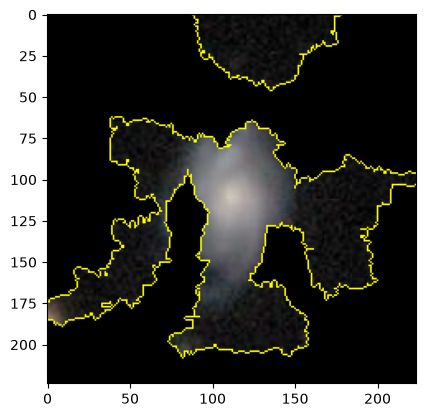

In [12]:
# Plot mask with positive contributions
label_to_explain = 0
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[label_to_explain],
    positive_only=True,
    negative_only=False,
    num_features=10,
    hide_rest=True,
    min_weight=0,
)
normalized_temp = temp / 255.0
img_boundry1 = mark_boundaries(normalized_temp, mask)
plt.imshow(img_boundry1)

In this first example, we set ```num_features=10```, meaning that we want to extract the top 10 features (segmented areas) that contribute most to predicting this galaxy class. In other words, our model heavily depends on the ten segmented areas to recognize the shape of the galaxy. Try to change this parameter and see what happens.

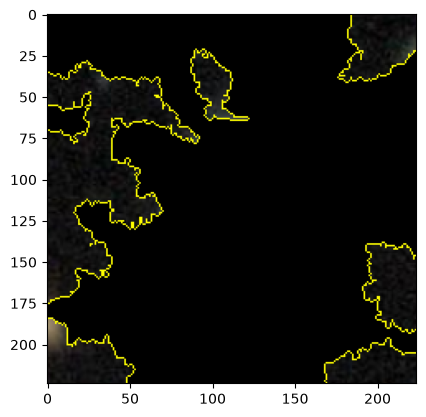

In [13]:
# Plot mask with negative contributions
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[label_to_explain],
    positive_only=False,
    negative_only=True,
    num_features=10,
    hide_rest=True,
    min_weight=0,
)
normalized_temp = temp / 255.0
img_boundry2 = mark_boundaries(normalized_temp, mask)
plt.imshow(img_boundry2)

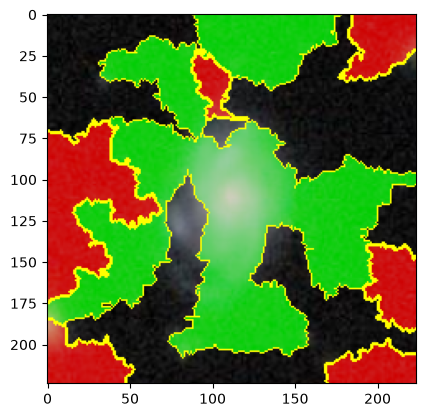

In [14]:
# Plot mask with both positive and negative contributions
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[label_to_explain],
    positive_only=False,
    negative_only=False,
    num_features=20, # increased to show more superpixels
    hide_rest=False,
    min_weight=0,
)
normalized_temp = temp/255.0
img_boundry3 = mark_boundaries(normalized_temp, mask)
plt.imshow(img_boundry3)

**Fidelity of the explanation**

As in the Random Forest LIME notebook ([*Gen-2-Tutorial_LIME.ipynb*](../xai-for-random-forest/Gen-2-Tutorial_LIME.ipynb)), we can quantify how well the simple surrogate model approximates the predictions of the complex model in the neighborhood of our instance — the explanation's **fidelity**. LIME fits a weighted linear model on the perturbed images, and the goodness of fit of that surrogate is stored in `explanation.score` as an $R^2$ value (it refers to the top predicted class, i.e. the one we visualized above). The closer the $R^2$ is to 1, the better the surrogate reproduces the model's behavior on the neighborhood samples, and the more we can trust the explanation.

*Note: for image data this $R^2$ is usually **considerably lower** than in the tabular Random Forest case. Approximating a deep CNN with a linear model over a few hundred on/off superpixel perturbations is a much coarser approximation than fitting a linear model to a handful of tabular features, so a modest value here is expected — it is a reminder to interpret image LIME explanations with extra caution, not a sign that something went wrong.*

In [15]:
# Fidelity of the local surrogate model: the R^2 of LIME's linear approximation
# for the top predicted class. As in the Random Forest notebook, values closer
# to 1 mean a better approximation; for image LIME this is typically lower.
explanation.score

0.6483262661542626

<font color='green'>

#### Question 3: Which are the pros and cons of LIME?

<font color='grey'>

#### Your Answer: 
Pros of LIME for Images:
- Model Agnosticism: Works with any ML model.
- Local Explanations: Provides insights for individual instances.
- Human Interpretability: Generates human-readable explanations.
- Versatility: Applicable to various data types.
  
Cons of LIME for Images:
- Sensitivity to Parameters: Parameter choices impact results (for example segmentation algorithm for superpixel definition, distance metric for superpixel weights, number of perturbed images, kernel_width/regularization surrogate model).
- Local Approximation: Captures local, not global, model behavior.
- Interpretability Challenges: Visualizations may be complex.
- Computational Cost: Can be resource-intensive.


<font color='green'>

#### Question 4: How do you think that the number of perturbed samples influences the stability of LIME explanations for image predictions?

<font color='grey'>

#### Your Answer:
Increasing the number of perturbed samples generally improves stability but comes at the cost of increased computation time. A balance is needed based on the desired level of stability and available resources.

<font color='green'>

#### Question 5: In the context of LIME for images, why do we perturb the input image by changing regions (superpixels) before generating explanations?

<font color='grey'>

#### Your Answer:
Perturbing the image helps understand the model's sensitivity to different regions, allowing LIME to approximate the local decision boundary around a specific instance.  

--------

<font color='green'>

#### Task: Apply LIME to an Ambiguous Galaxy

In this exercise, you will apply **LIME** to a galaxy that the model finds hard to classify, in order to investigate how the model separates two similar shapes. An edge-on disk and a smooth cigar are both elongated, and the model is almost undecided between them for this image.

Your task is to:

1. Load and preprocess the new image.
2. Run inference with the fine-tuned model and inspect the predicted probabilities for all four classes.
3. Identify the two classes with the highest probabilities.
4. Generate LIME explanations for both classes separately.
5. Visualize and compare the resulting explanations.
6. Analyze which image regions contribute to the model predicting one shape versus the other.

> **Hint:** LIME explanations are class-specific. The highlighted image regions may therefore differ between the two classes, even though the image and the model stay the same.

Predicted probabilities:
0: smooth round     0.001
1: smooth cigar     0.518
2: edge-on disk     0.480
3: unbarred spiral  0.000


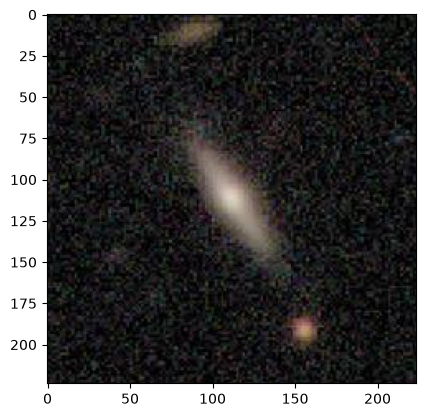

In [16]:
path_to_img = '../data/images/galaxies/test_galaxy_1926.jpg'
img = utils.read_image_PIL(path_to_img)

# Make prediction and print the probability of every class
pred = utils.batch_predict([pill_transf(img)], model)

print("Predicted probabilities:")
for i, (name, p) in enumerate(zip(GALAXY_CLASSES, pred.squeeze())):
    print(f"{i}: {name:16s} {p:.3f}")

plt.imshow(img)

In [17]:
# Define explainer
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(image=np.array(pill_transf(img)), 
                                         classifier_fn=lambda images: utils.batch_predict(images, model), 
                                         top_labels=4, 
                                         hide_color=None, 
                                         num_samples=1000,
                                         random_seed=42) 

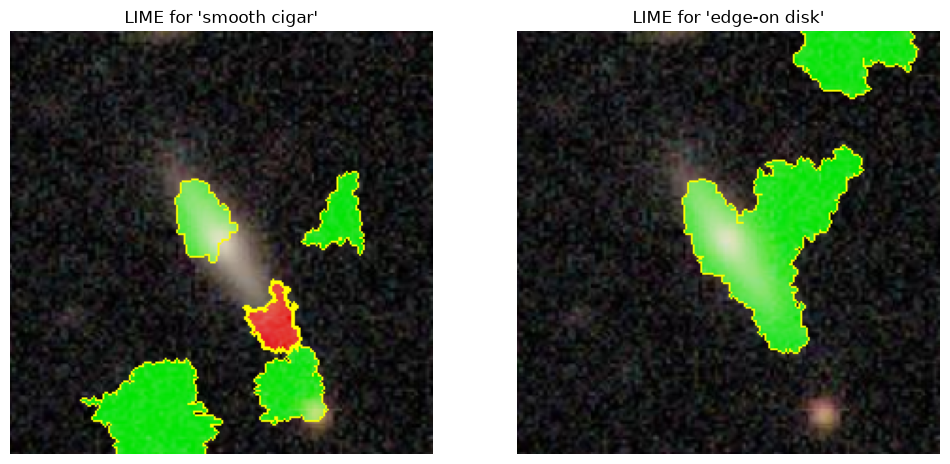

In [18]:
# Plot mask with positive contributions
label_to_explain = 0
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[label_to_explain],
    positive_only=False,
    negative_only=False,
    num_features=5,
    hide_rest=False,
    min_weight=0,
)
normalized_temp = temp / 255.0
img_boundry0 = mark_boundaries(normalized_temp, mask)

label_to_explain = 1
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[label_to_explain],
    positive_only=False,
    negative_only=False,
    num_features=5,
    hide_rest=False,
    min_weight=0,
)
normalized_temp = temp / 255.0
img_boundry1 = mark_boundaries(normalized_temp, mask)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Creating a figure with two subplots

# Plotting the explanation for the most likely class
axes[0].imshow(img_boundry0)
axes[0].set_title(f"LIME for '{GALAXY_CLASSES[explanation.top_labels[0]]}'")
axes[0].axis('off')

# Plotting the explanation for the second most likely class
axes[1].imshow(img_boundry1)
axes[1].set_title(f"LIME for '{GALAXY_CLASSES[explanation.top_labels[1]]}'")
axes[1].axis('off')

plt.show()